# Combined Model Chromatin Deconvolution

May 17, 2025

- Updated deconvolution model with 128 index branch length (better smoothing with symmlet par=5)
- Improved edge effect handling (periodic and mirror effect handling)
- Alpha parameter estimation from daughter-specific gene expression (32, 16)


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [118]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs()
config1.alpha

32

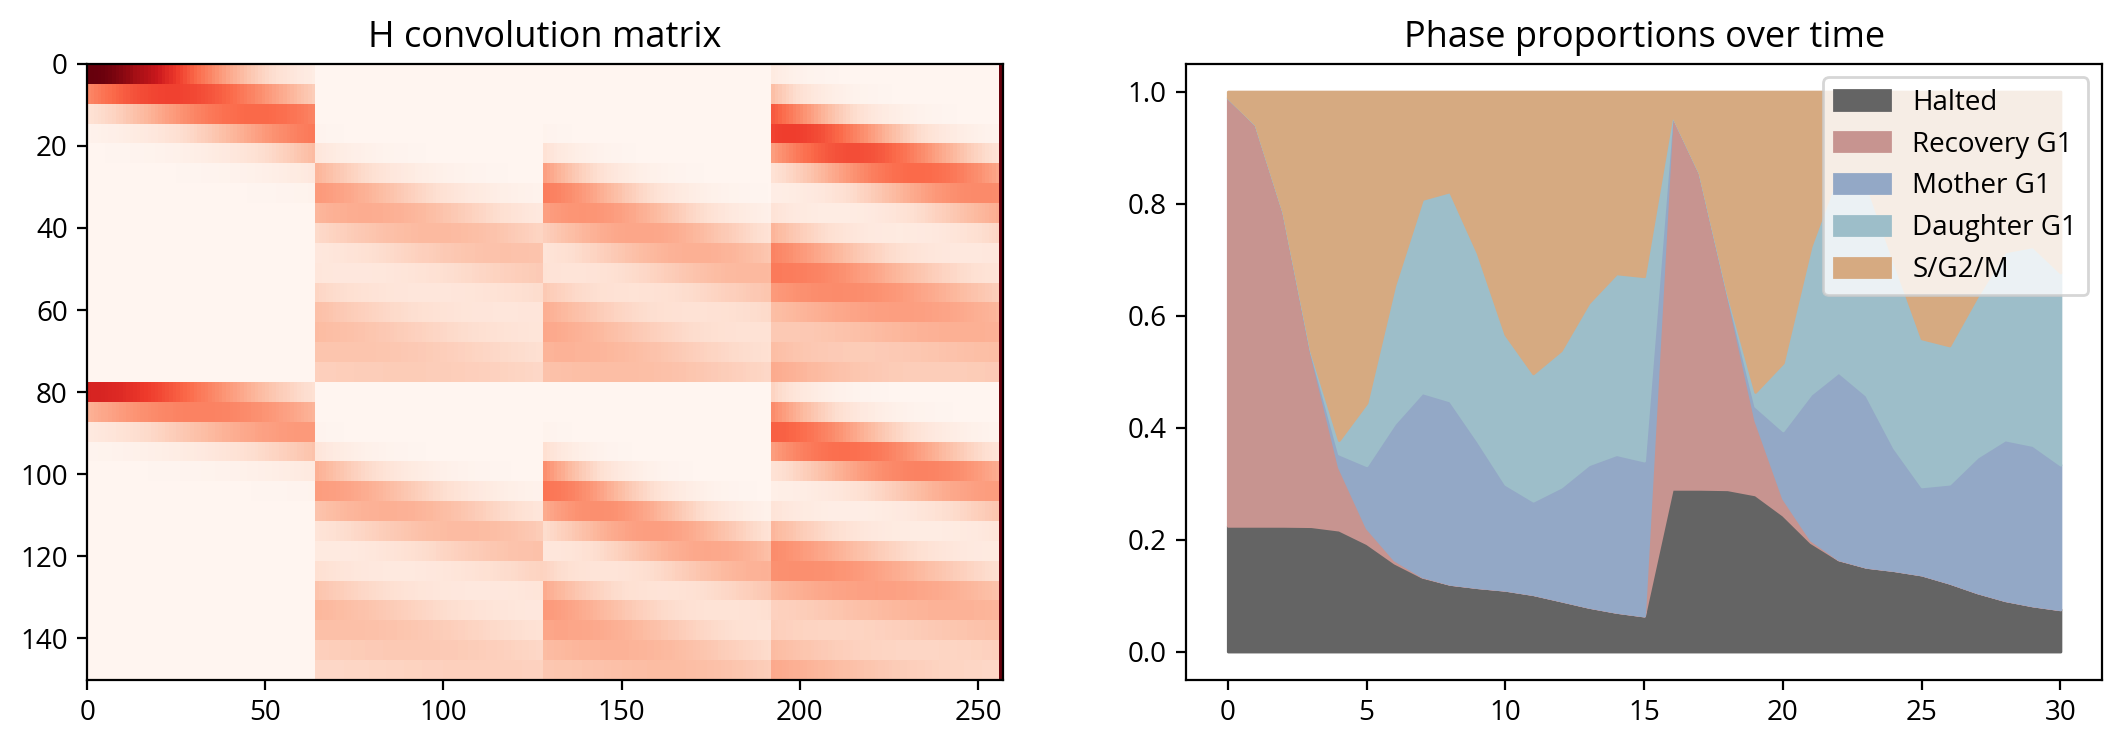

In [119]:
config1.plot_H(np.concatenate([config1.H, config2.H]))

In [120]:
from src.combined_chromatin_model import CombinedChromatinModel
combined_model = CombinedChromatinModel(config1=config1, config2=config2)

In [121]:
from src.origins import load_origins

origins = load_origins()

origin = origins[origins.ars_name == 'ARS714'].iloc[0]
origin

span = 800
span_2 = span//2
chrom = origin.chr
mnase_span = origin.pos-span_2, origin.pos+span_2
combined_model.load_mnase_span(chrom, mnase_span)


Loading chromosome reads: 7
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 799) to (16, 26, 80)
Loading chromosome reads: 7
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 799) to (15, 26, 80)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


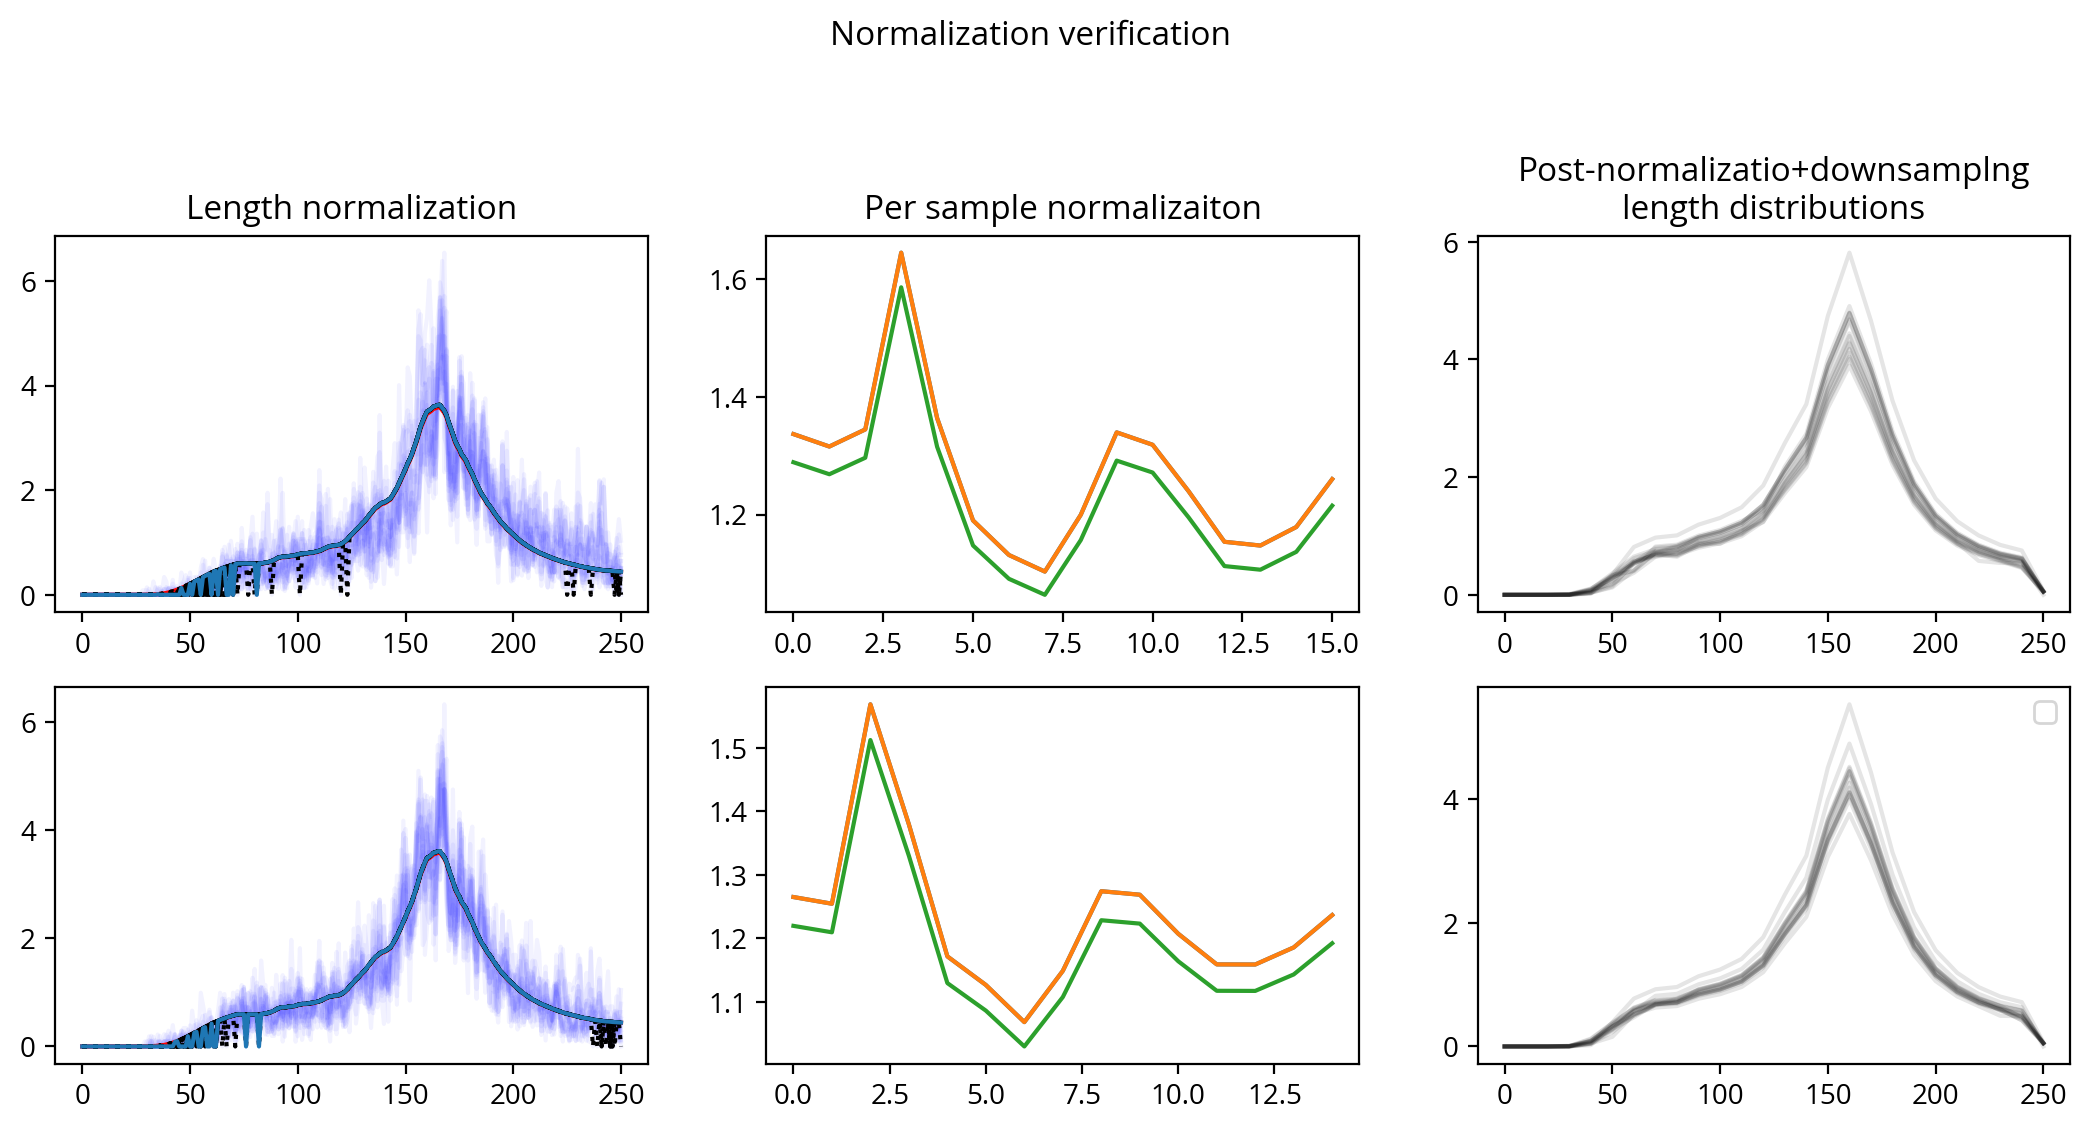

In [122]:
fig = combined_model.plot_normalization_sanity_check()

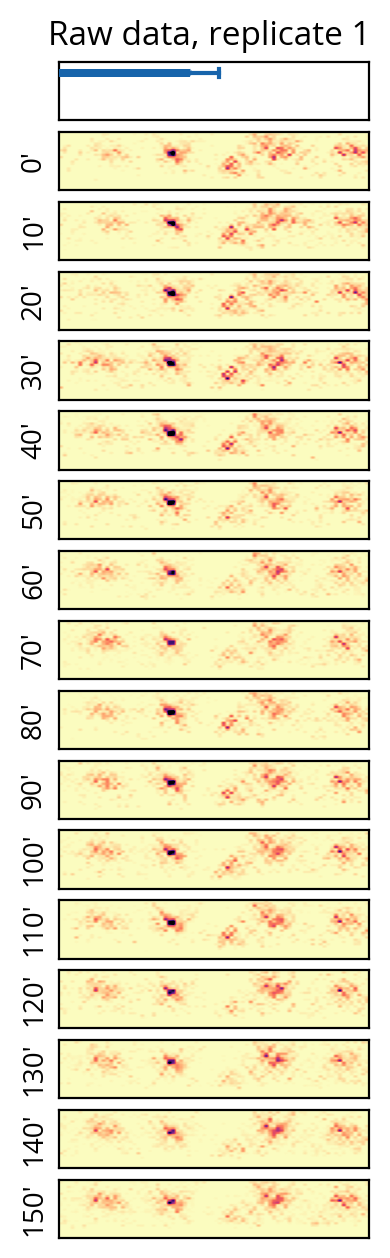

In [123]:
fig = combined_model.chrom1_model.plot_raw_data(figsize=(2, 7))

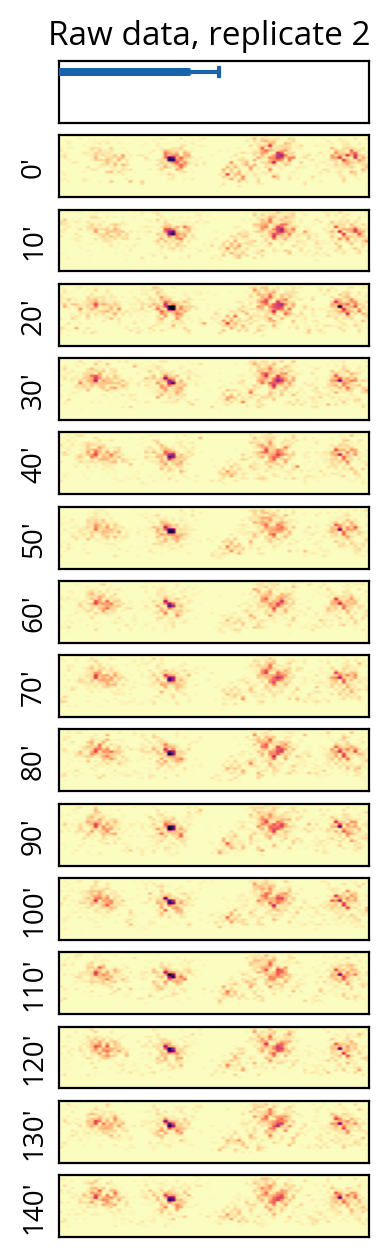

In [124]:
fig = combined_model.chrom2_model.plot_raw_data(figsize=(2, 7))

In [125]:
combined_model.setup_deconv_model(copy_correct=False)

Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr


In [ ]:
kappa = 0.01
combined_model.deconvolve(gamma=0.14, kappa=kappa, verbose=True)
combined_model.plot_branches(figsize=(7, 7))

0/2080 - 00:00:00.001
500/2080 - 00:00:23.259


In [ ]:
f_imgs = combined_model.F.reshape((217, 26, -1))

plt.plot(config1.get_timepoints_for_branch('i'),
         f_imgs[config1.i_indices(), :12, 35:55].mean((1, 2)))
plt.plot(config1.get_timepoints_for_branch('t'),
         f_imgs[config1.t_indices(), :12, 35:55].mean((1, 2)))
plt.plot(config1.get_timepoints_for_branch('b'), 
         f_imgs[config1.b_indices(), :12, 35:55].mean((1, 2)))
plt.ylim(0, 2)